In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

### Zadanie 4. Ścieżki ewolucji gwiazd

#### 4.1

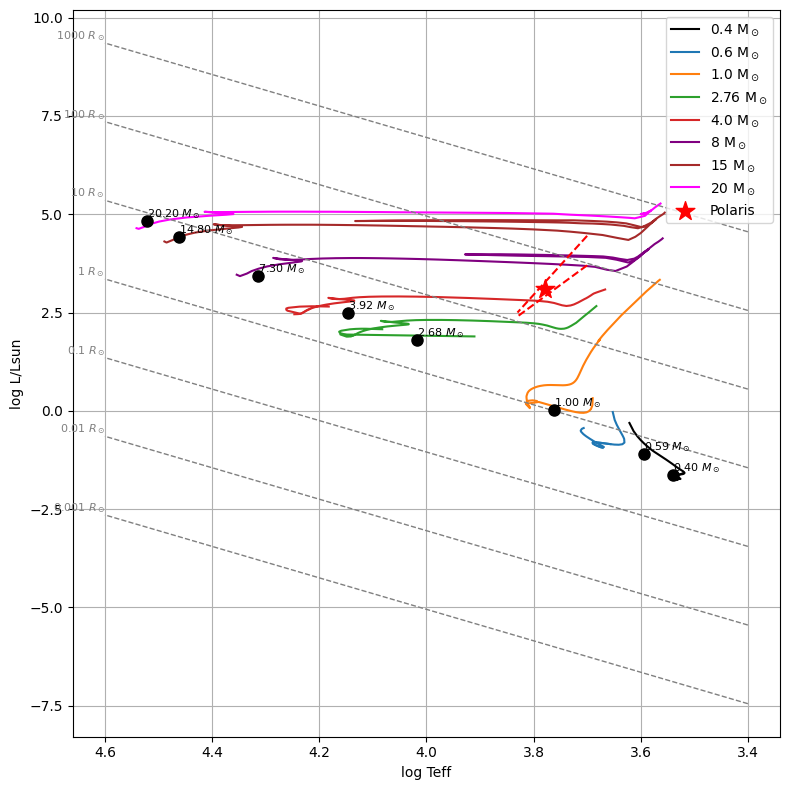

In [10]:
# Evolutionary tracks for different masses



fig, ax = plt.subplots(figsize=(8, 8), tight_layout=True)

file_names = ["_04", "_06", "_10", "_27", "_40"]
colors = ["#000000", "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # black, blue, orange, green, red
labels = [r"0.4 $\rm M_\odot$", r"0.6 $ \rm M_\odot$", r"1.0 $\rm M_\odot$", r"2.76 $\rm M_\odot$", r"4.0 $\rm M_\odot$"]

path_to_files = r"/media/olehryz/Elements/progs/univ_codes/2025_2026/semester_02/inner_stars/tracks"

for name in file_names:
    
    name1 = f"o.track1{name}"
    file1 = os.path.join(path_to_files, name1)

    data1 = pd.read_csv(file1, delim_whitespace=True, skiprows=1,
                       names=["N", "Age(Gyr)", "log_Teff", "log_L_Lsun", "Ycore", "Mcore"])
    ax.plot(data1["log_Teff"], data1["log_L_Lsun"], color=colors[file_names.index(name)])


    name2 = f"o.track2{name}"
    file2 = os.path.join(path_to_files, name2)

    data2 = pd.read_csv(file2, delim_whitespace=True, skiprows=1,
                       names=["N", "Age(Gyr)", "log_Teff", "log_L_Lsun", "Ycore", "Mcore"])
    ax.plot(data2["log_Teff"], data2["log_L_Lsun"], label=labels[file_names.index(name)], color=colors[file_names.index(name)])

ms_files = [
    ("ms0800z019s.dat", "8 $\\rm M_\\odot$", "purple"),
    ("ms1500z019s.dat", "15 $\\rm M_\\odot$", "brown"),
    ("ms2000z019s.dat", "20 $\\rm M_\\odot$", "magenta"),
]

for fname, label, color in ms_files:
    ms_path = os.path.join(path_to_files, fname)
    ms_data = pd.read_csv(ms_path, delim_whitespace=True, comment="#", engine="python")
    ax.plot(ms_data["logTef"], ms_data["logL"], label=label, color=color)
    # ms_data.info()



# Stable radii lines
R_sun = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
log_Teff_range = np.linspace(3.4, 4.6, 200)  # zakres typowy dla HR diagramu
T_sun = 5777
log_T_sun = np.log10(T_sun)

for R in R_sun:
    logL = 2 * np.log10(R) + 4 * log_Teff_range - 4 * log_T_sun
    ax.plot(log_Teff_range, logL, '--', color='gray', lw=1)
    idx = -1 
    ax.text(log_Teff_range[idx], logL[idx], f"{R} $R_\\odot$", color='gray', fontsize=8, va='bottom', ha='right', rotation=0)



# MS stars of silimar masses  

sim_path = os.path.join(path_to_files, "similar_masses")
sim_data = pd.read_csv(sim_path, delim_whitespace=True, comment="#", engine="python")

# Ustal nagłówki kolumn (na podstawie pliku)
# sim_data.columns = [
#     "SpT", "Teff", "logT", "BCv", "logL", "Mbol", "R_Rsun", "Mv", "B-V", "Bt-Vt", "G-V", "Bp-Rp", "G-Rp", "M_G",
#     "b-y", "U-B", "V-Rc", "V-Ic", "V-Ks", "J-H", "H-Ks", "M_J", "M_Ks", "Ks-W1", "W1-W2", "W1-W3", "W1-W4",
#     "g-r", "i-z", "z-Y", "Msun", "SpT_1"
# ]

target_masses = [0.4, 0.6, 1.0, 2.76, 4.0, 8, 15, 20]

# Dla każdej masy znajdź najbliższą w tabeli
for m in target_masses:
    idx = (sim_data["Msun"] - m).abs().idxmin()
    row = sim_data.loc[idx]
    ax.plot(row["logT"], row["logL"], marker="o", color="k", markersize=8, zorder=10)
    ax.text(row["logT"], row["logL"], f"{row['Msun']:.2f} $M_\\odot$", color="k", fontsize=8, va='bottom', ha='left')

#https://www.pta.edu.pl/pliki/proc/vol13/v13p163.pdf
#https://www.aanda.org/articles/aa/pdf/2016/07/aa28031-15.pdf
logT = np.linspace(3.7, 3.83, 100)
logL_up = -15.0 * (logT - 3.77) + 3.4
logL_down = -10 * (logT - 3.77) + 3.0
ax.plot(logT, logL_up, color='red', linestyle='--')
ax.plot(logT, logL_down, color='red', linestyle='--')


logT_polaris = np.log10(6000)   # ~3.78
logL_polaris = np.log10(1.26e3) # ~3.10

ax.scatter(logT_polaris, logL_polaris, color='red', marker='*', s=200, label='Polaris')

ax.invert_xaxis()  # HR diagram: Teff decreases to the right
ax.set_xlabel("log Teff")
ax.set_ylabel("log L/Lsun")
ax.grid()
ax.legend()
plt.show()

#### 4.2

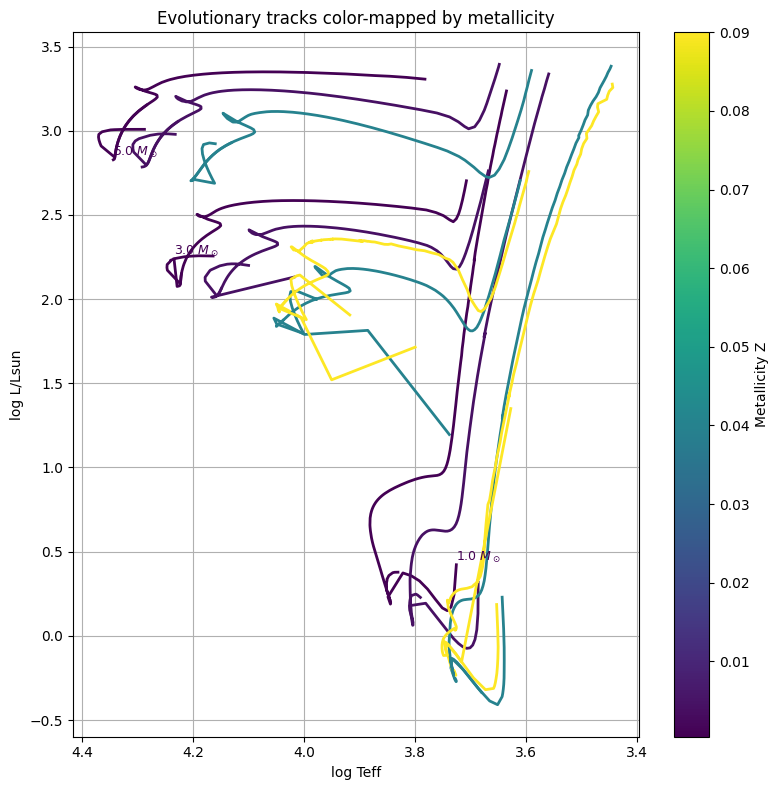

In [17]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# --- CONFIGURATION ---
tracks_dir = "/media/olehryz/Elements/progs/univ_codes/2025_2026/semester_02/inner_stars/z_tracks"
track_files = glob.glob(os.path.join(tracks_dir, "o.track*"))

# Helper: extract metallicity and mass from filename, e.g. o.track1_1_04 (mass=1, Z=0.04)
def parse_mass_z(filename):
    # Example: o.track1_1_04 -> mass=1, Z=0.04
    base = os.path.basename(filename)
    parts = base.replace("o.track", "").split("_")
    if len(parts) >= 3:
        mass = float(parts[1])
        part_z = parts[2]
        if part_z == "0004":
            z = 0.0004
        elif part_z == "004":
            z = 0.004
        elif part_z == "04":
            z = 0.04
        elif part_z == "09":
            z = 0.09
        else:
            return ValueError(f"Unknown metallicity format in filename: {filename}")
        return mass, z
    return None, None

# Gather all metallicities for normalization
all_z = []
for f in track_files:
    _, z = parse_mass_z(f)
    if z is not None:
        all_z.append(z)
all_z = np.array(all_z)
norm = Normalize(vmin=all_z.min(), vmax=all_z.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(8, 8), tight_layout=True)

for file in track_files:
    mass, z = parse_mass_z(file)
    if z is None or mass is None:
        continue
    color = cmap(norm(z))
    data = pd.read_csv(file, delim_whitespace=True, skiprows=1,
                       names=["N", "Age(Gyr)", "log_Teff", "log_L_Lsun", "Ycore", "Mcore"])
    ax.plot(data["log_Teff"], data["log_L_Lsun"], color=color, lw=2)
    # Label the first point with mass
    if z == 0.0004 and file.split("/")[-1].startswith("o.track1"):  # Label only the lowest metallicity track to avoid clutter
        ax.text(data["log_Teff"].iloc[0], data["log_L_Lsun"].iloc[0], f"{mass} $M_\\odot$", color=color, fontsize=9, va='bottom', ha='left')

# Colorbar for metallicity
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax, label="Metallicity Z")

ax.invert_xaxis()
ax.set_xlabel("log Teff")
ax.set_ylabel("log L/Lsun")
ax.set_title("Evolutionary tracks color-mapped by metallicity")
ax.grid()
plt.show()

#### 4.3